# QAOA Tutorial for Max-Cut

This notebook is organized into the following four main steps:

1. Start with a Max-Cut graph example.
2. Construct the corresponding Hamiltonian and QAOA circuit.
3. Solve the QAOA optimization problem.
4. Visualize the results.

After that, we repeat the same experiment with a noise model derived from a fake IBM backend to compare the noiseless and noisy cases.

## Imports

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from qaoa_maxcut import (
    assignment_to_partition,
    build_graph,
    build_fake_backend_simulator,
    build_maxcut_hamiltonian,
    build_qaoa_circuit,
    FakeBackendConfig,
    SGDConfig,
    cut_value,
    draw_graph,
    optimal_solution_probability,
    plot_sampling_distribution,
    rank_assignments,
    solve_maxcut_instance,
    sweep_qaoa_layers,
)

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Start with a Max-Cut Example

We begin by explicitly specifying a graph. All Hamiltonians, circuits, and optimization steps below are built for this graph.

Nodes: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4)]


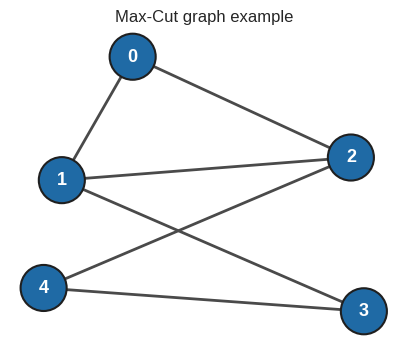

In [23]:
example_edges = [
    (0, 1),
    (0, 2),
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
]

graph = build_graph(example_edges)
print('Nodes:', list(graph.nodes()))
print('Edges:', list(graph.edges()))

draw_graph(graph, title='Max-Cut graph example');

## 2. Construct the Hamiltonian and QAOA Circuit

For Max-Cut, a standard cost Hamiltonian is:

$$
H_C = \sum_{(i,j) \in E} \frac{1}{2}(I - Z_i Z_j)
$$

Each edge contributes one term. If the two endpoints are assigned to different partitions, that edge contributes 1 to the cut. QAOA alternates between:

- the cost unitary generated by $H_C$
- the mixer unitary, typically based on $H_M = \sum_i X_i$


In [24]:
hamiltonian = build_maxcut_hamiltonian(graph)
print('Max-Cut Hamiltonian:')
print(hamiltonian)

Max-Cut Hamiltonian:
SparsePauliOp(['IIIII', 'IIIZZ', 'IIZIZ', 'IIZZI', 'IZIZI', 'ZIZII', 'ZZIII'],
              coeffs=[ 3. +0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j])


In [25]:
layers = 2
optimizer_name = 'SGD'
sgd_config = SGDConfig(
    steps=30,
    learning_rate=0.10,
    gradient_step=0.08,
    learning_rate_decay=0.03,
)

print('Notebook optimizer:', optimizer_name)
print('SGD config:', sgd_config)


Notebook optimizer: SGD
SGD config: SGDConfig(steps=30, learning_rate=0.1, gradient_step=0.08, learning_rate_decay=0.03)


The circuit below is the parameterized QAOA ansatz for the selected graph and depth.


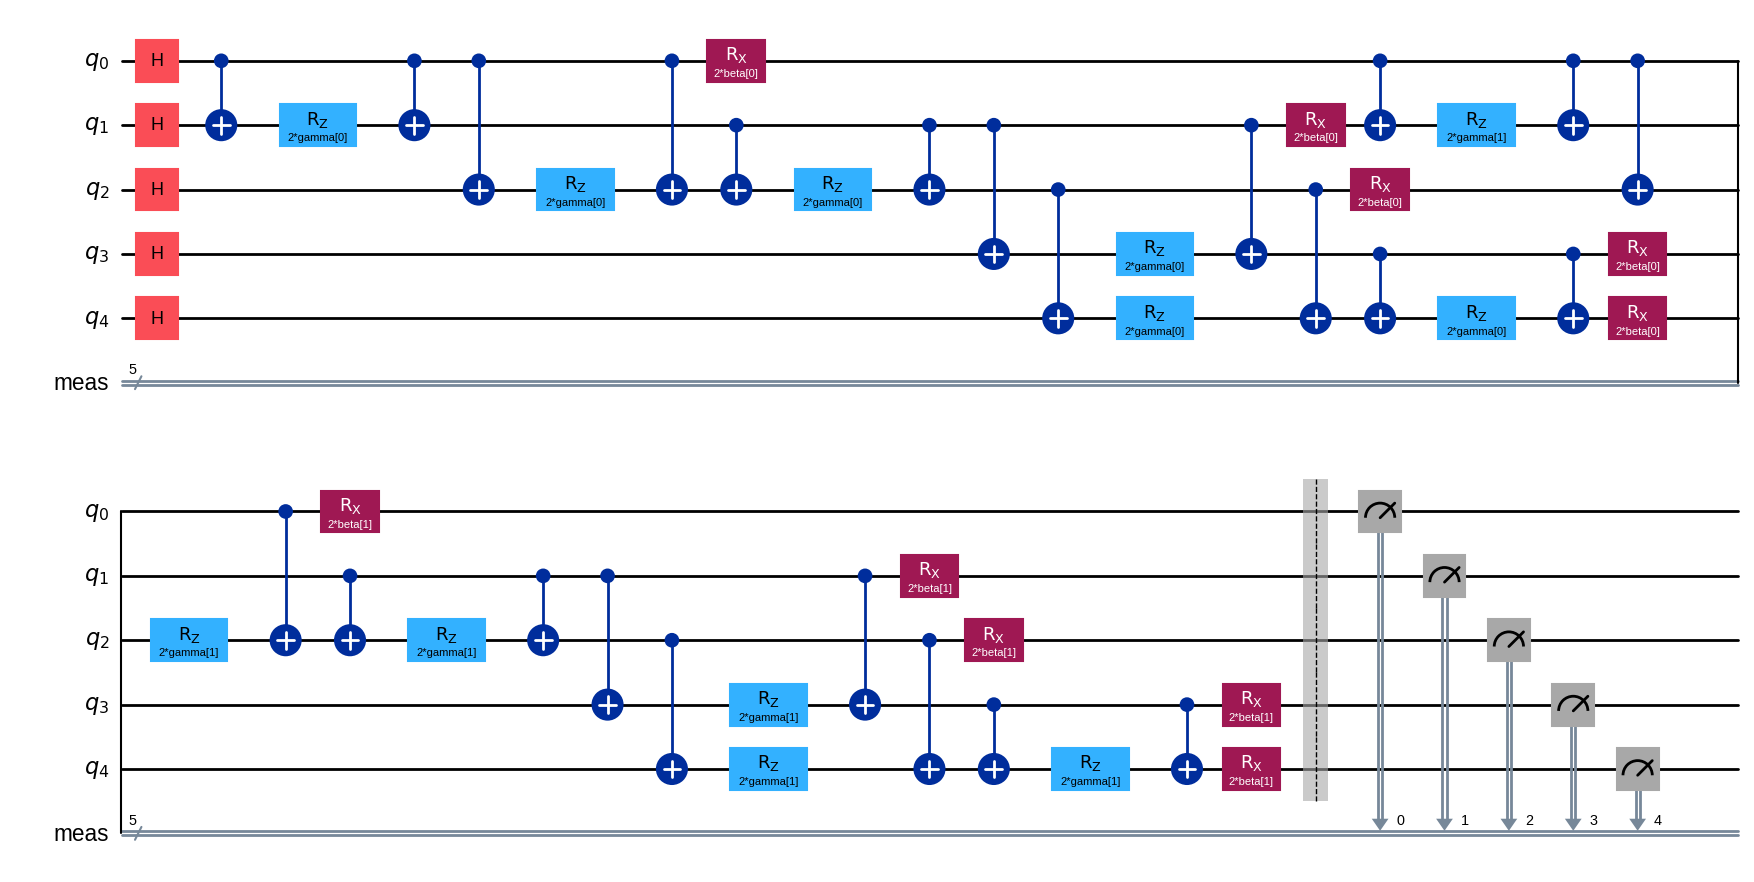

Circuit depth: 31
Number of qubits: 5


In [26]:
qaoa_circuit, gamma_params, beta_params = build_qaoa_circuit(graph, layers)
display(qaoa_circuit.draw('mpl'))
print('Circuit depth:', qaoa_circuit.depth())
print('Number of qubits:', qaoa_circuit.num_qubits)


The following bitstring example illustrates how a cut is encoded. For example, `00110` means:

- nodes with bit `0` are placed on one side
- nodes with bit `1` are placed on the other side

assignment: 00110
partition: [0, 1, 4] | [2, 3]
cut value: 5


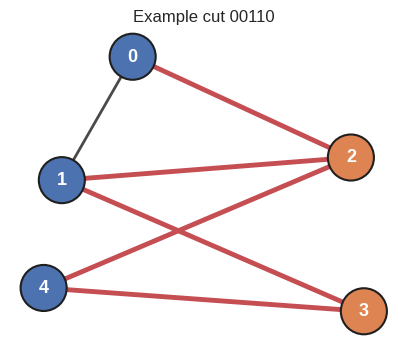

In [27]:
example_assignment = '00110'
left, right = assignment_to_partition(example_assignment)
print('assignment:', example_assignment)
print('partition:', left, '|', right)
print('cut value:', cut_value(example_assignment, graph))

draw_graph(graph, assignment=example_assignment, title=f'Example cut {example_assignment}');

## 3. Solve QAOA

In this step we do two things:

- use a classical optimizer to search for the QAOA parameters `gamma` and `beta`
- compute the exact optimum by brute force for comparison

In [28]:
solution = solve_maxcut_instance(
    edges=example_edges,
    layers=layers,
    shots=2048,
    restarts=8,
    seed=7,
    optimizer=optimizer_name,
    sgd_config=sgd_config,
)

result = solution.result
exact_cut = solution.exact_cut
exact_assignments = solution.exact_assignments
optimal_prob = optimal_solution_probability(result.counts, graph, exact_assignments)

print('Optimizer used:', optimizer_name)
print('Expected cut value from QAOA: {:.4f}'.format(result.expected_cut))
print('gamma =', np.round(result.x[:layers], 6).tolist())
print('beta  =', np.round(result.x[layers:], 6).tolist())
print('Exact optimum cut value:', exact_cut)
print('Optimal assignments:', exact_assignments)
print('Probability of sampling an optimal solution: {:.4%}'.format(optimal_prob))
print('len(iteration_history) =', len(result.iteration_history), '(expected', sgd_config.steps + 1, 'for SGD)')


Optimizer used: SGD
Expected cut value from QAOA: 4.6289
gamma = [2.621249, 1.263472]
beta  = [0.309118, 0.506737]
Exact optimum cut value: 5
Optimal assignments: ['00110', '01001', '10110', '11001']
Probability of sampling an optimal solution: 71.2891%
len(iteration_history) = 31 (expected 31 for SGD)


## 4. Visualize the Results

We present the noiseless results from three angles:

- the objective value during optimization
- the sampling distribution over all possible bitstrings in computational-basis order
- a visualization of the best sampled cut

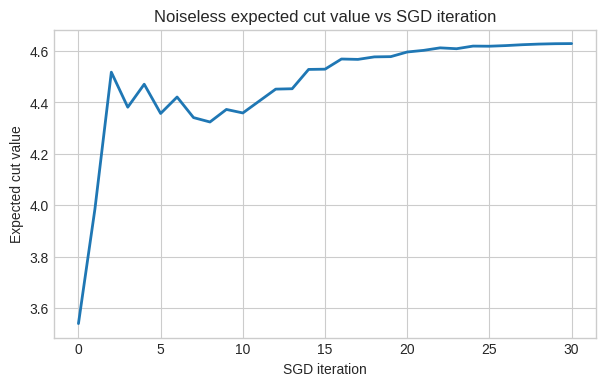

In [29]:
x_noiseless = np.arange(len(result.iteration_history))

plt.figure(figsize=(7, 4))
plt.plot(x_noiseless, result.iteration_history, linewidth=2)
plt.xlabel('SGD iteration')
plt.ylabel('Expected cut value')
plt.title('Noiseless expected cut value vs SGD iteration')
plt.xticks(np.arange(0, len(x_noiseless), 5));


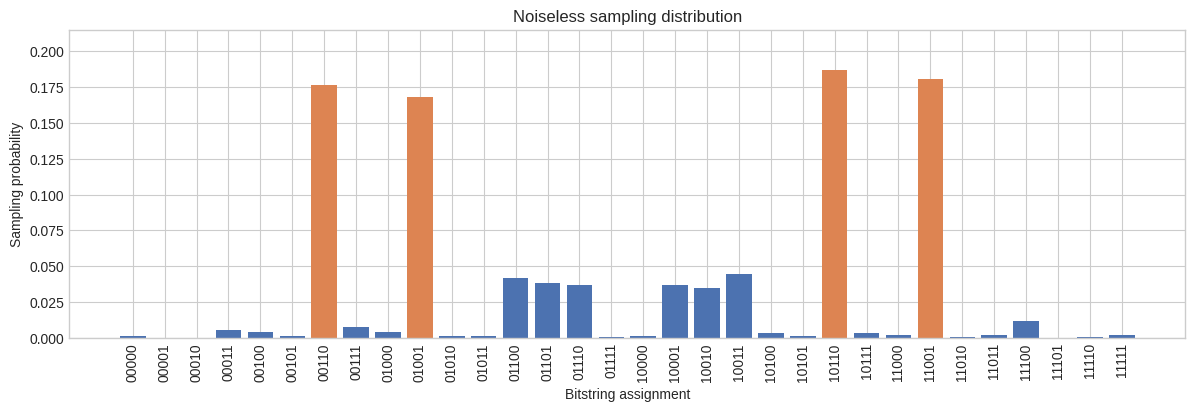

In [30]:
plot_sampling_distribution(result.counts, graph, title='Noiseless sampling distribution');

In [31]:
ranked = rank_assignments(result.cut_distribution, graph, limit=5)
for assignment, frequency, value in ranked:
    left, right = assignment_to_partition(assignment)
    print(f'assignment={assignment}  shots={frequency:4d}  cut={value}  partition={left} | {right}')

assignment=10110  shots= 383  cut=5  partition=[1, 4] | [0, 2, 3]
assignment=11001  shots= 370  cut=5  partition=[2, 3] | [0, 1, 4]
assignment=00110  shots= 362  cut=5  partition=[0, 1, 4] | [2, 3]
assignment=01001  shots= 345  cut=5  partition=[0, 2, 3] | [1, 4]
assignment=10011  shots=  91  cut=4  partition=[1, 2] | [0, 3, 4]


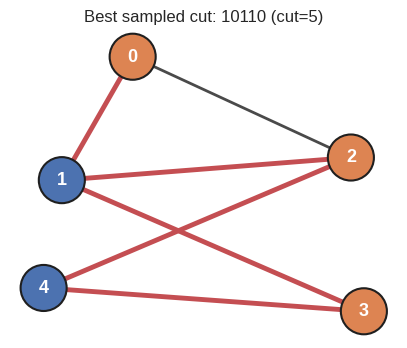

In [32]:
best_assignment = ranked[0][0]
best_cut = cut_value(best_assignment, graph)
draw_graph(graph, assignment=best_assignment, title=f'Best sampled cut: {best_assignment} (cut={best_cut})');

In [33]:
print('Best exact cut value:', exact_cut)
print('One optimal assignment:', exact_assignments[0])
print('Best sampled assignment:', best_assignment)
print('Best sampled cut value:', best_cut)
print('Approximation ratio:', best_cut / exact_cut)
print('Probability of sampling an optimal solution: {:.4%}'.format(optimal_prob))

Best exact cut value: 5
One optimal assignment: 00110
Best sampled assignment: 10110
Best sampled cut value: 5
Approximation ratio: 1.0
Probability of sampling an optimal solution: 71.2891%


## Additional Experiment: Repeat with a Fake IBM Backend Noise Model

The previous experiment used a noiseless simulator. Now we rerun the same graph with a noise model derived from a fake IBM backend.

This gives us a more device-like noisy model, including basis gates, coupling map, and backend-derived error data.

This section requires both `qiskit-aer` and `qiskit-ibm-runtime`.

In [34]:
fake_backend_config = FakeBackendConfig(backend_name='FakeManilaV2')
fake_backend, noisy_backend = build_fake_backend_simulator(fake_backend_config)
print(fake_backend_config)
print(fake_backend)

FakeBackendConfig(backend_name='FakeManilaV2')


In [35]:
noisy_solution = solve_maxcut_instance(
    edges=example_edges,
    layers=layers,
    shots=2048,
    restarts=8,
    seed=7,
    optimizer=optimizer_name,
    sgd_config=sgd_config,
    simulator_backend=noisy_backend,
)

noisy_result = noisy_solution.result
noisy_optimal_prob = optimal_solution_probability(noisy_result.counts, graph, exact_assignments)
print('Noisy optimizer used:', optimizer_name)
print('Noisy expected cut value: {:.4f}'.format(noisy_result.expected_cut))
print('Noisy gamma =', np.round(noisy_result.x[:layers], 6).tolist())
print('Noisy beta  =', np.round(noisy_result.x[layers:], 6).tolist())
print('Probability of sampling an optimal solution under noise: {:.4%}'.format(noisy_optimal_prob))
print('Noisy len(iteration_history) =', len(noisy_result.iteration_history), '(expected', sgd_config.steps + 1, 'for SGD)')


Noisy optimizer used: SGD
Noisy expected cut value: 4.0342
Noisy gamma = [2.628838, 1.291914]
Noisy beta  = [0.263046, 0.510058]
Probability of sampling an optimal solution under noise: 45.4102%
Noisy len(iteration_history) = 31 (expected 31 for SGD)


<Axes: title={'center': 'Noisy sampling distribution'}, xlabel='Bitstring assignment', ylabel='Sampling probability'>

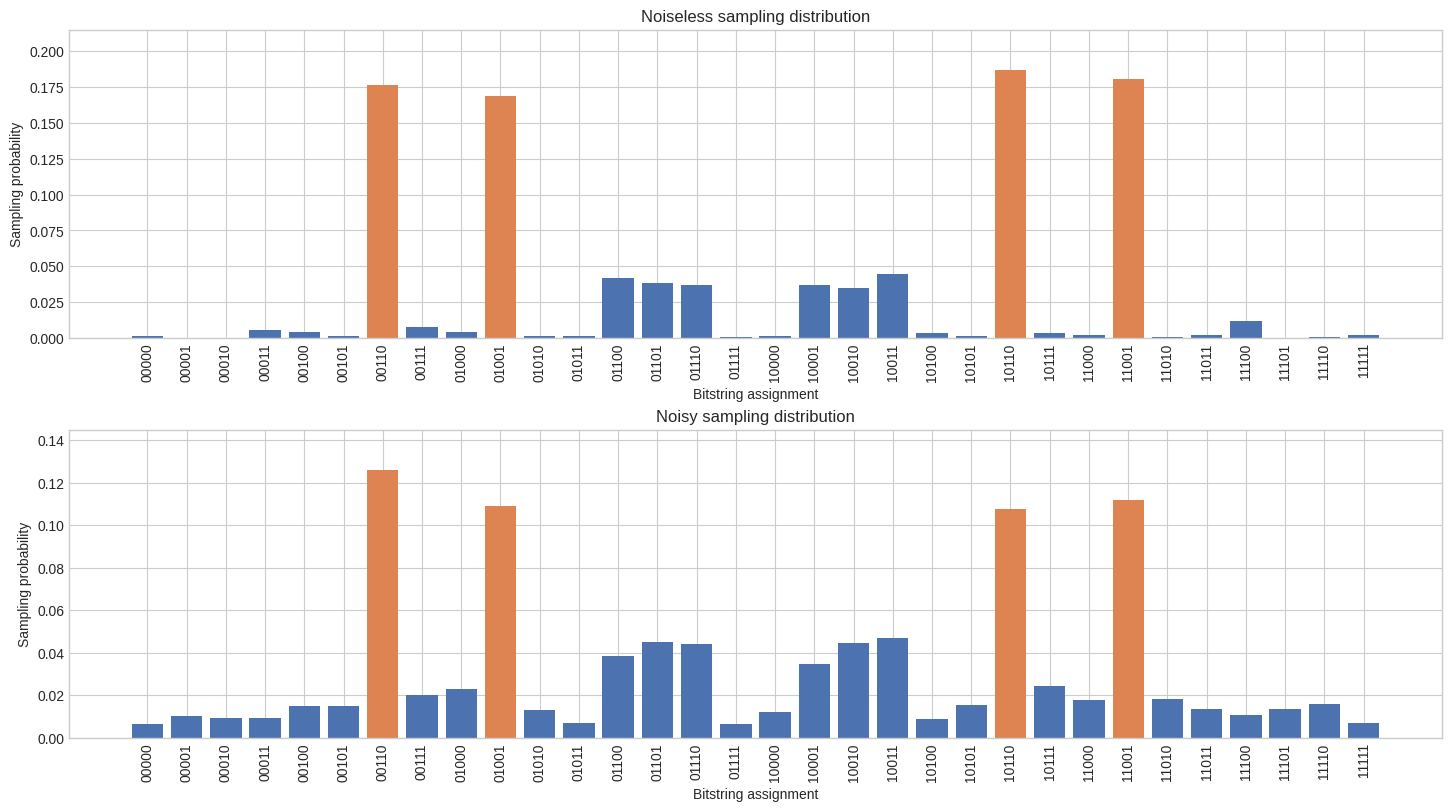

In [36]:
fig_width = max(8, 0.45 * (2 ** graph.number_of_nodes()))
fig, axes = plt.subplots(2, 1, figsize=(fig_width, 8), constrained_layout=True)
plot_sampling_distribution(result.counts, graph, ax=axes[0], title='Noiseless sampling distribution')
plot_sampling_distribution(noisy_result.counts, graph, ax=axes[1], title='Noisy sampling distribution')

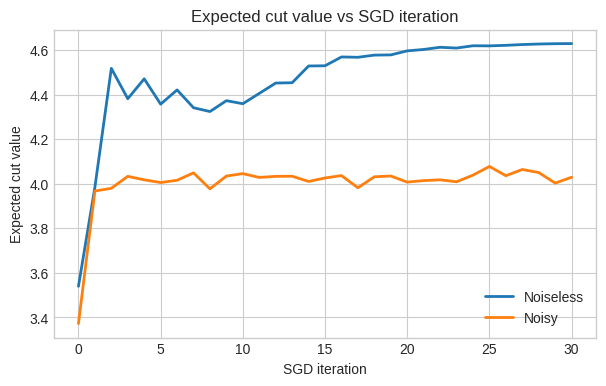

In [37]:
expected_len = sgd_config.steps + 1
if optimizer_name.upper() != 'SGD':
    print('Warning: optimizer_name is not SGD. This plot is intended for SGD traces.')
if len(result.iteration_history) != expected_len or len(noisy_result.iteration_history) != expected_len:
    print('Warning: iteration_history length mismatch. Re-run from imports after kernel restart.')

x_noiseless = np.arange(len(result.iteration_history))
x_noisy = np.arange(len(noisy_result.iteration_history))

plt.figure(figsize=(7, 4))
plt.plot(x_noiseless, result.iteration_history, label='Noiseless', linewidth=2)
plt.plot(x_noisy, noisy_result.iteration_history, label='Noisy', linewidth=2)
plt.xlabel('SGD iteration')
plt.ylabel('Expected cut value')
plt.title('Expected cut value vs SGD iteration')
plt.xticks(np.arange(0, max(len(x_noiseless), len(x_noisy)), 5))
plt.legend();


In [38]:
noisy_ranked = rank_assignments(noisy_result.cut_distribution, graph, limit=5)
for assignment, frequency, value in noisy_ranked:
    left, right = assignment_to_partition(assignment)
    print(f'assignment={assignment}  shots={frequency:4d}  cut={value}  partition={left} | {right}')

assignment=00110  shots= 258  cut=5  partition=[0, 1, 4] | [2, 3]
assignment=11001  shots= 229  cut=5  partition=[2, 3] | [0, 1, 4]
assignment=01001  shots= 223  cut=5  partition=[0, 2, 3] | [1, 4]
assignment=10110  shots= 220  cut=5  partition=[1, 4] | [0, 2, 3]
assignment=10011  shots=  96  cut=4  partition=[1, 2] | [0, 3, 4]


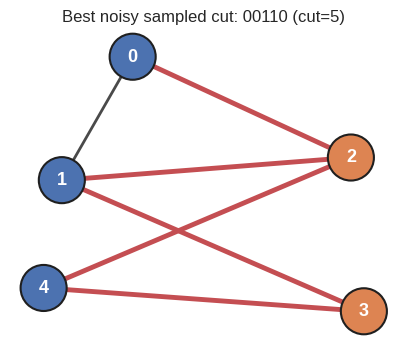

In [39]:
noisy_best_assignment = noisy_ranked[0][0]
noisy_best_cut = cut_value(noisy_best_assignment, graph)
draw_graph(graph, assignment=noisy_best_assignment, title=f'Best noisy sampled cut: {noisy_best_assignment} (cut={noisy_best_cut})');

In [40]:
print('Exact optimum cut value:', exact_cut)
print('Noiseless expected cut value: {:.4f}'.format(result.expected_cut))
print('Noisy expected cut value: {:.4f}'.format(noisy_result.expected_cut))
print('Best noiseless sampled cut:', best_cut)
print('Best noisy sampled cut:', noisy_best_cut)
print('Noiseless probability of sampling an optimal solution: {:.4%}'.format(optimal_prob))
print('Noisy probability of sampling an optimal solution: {:.4%}'.format(noisy_optimal_prob))

Exact optimum cut value: 5
Noiseless expected cut value: 4.6289
Noisy expected cut value: 4.0342
Best noiseless sampled cut: 5
Best noisy sampled cut: 5
Noiseless probability of sampling an optimal solution: 71.2891%
Noisy probability of sampling an optimal solution: 45.4102%


## Additional Experiment: Compare QAOA Depth $p$ with Fourier Warm Starts

Optimizing each depth independently becomes slower as $p$ grows. We use a Fourier warm-start heuristic: represent the QAOA angles in a Fourier basis and reuse learned Fourier coefficients when moving from depth $p-1$ to depth $p$.

The notebook helper follows the parameterization

$$\gamma_i = \sum_{k=1}^{q} u_k \sin\left[\left(k-\tfrac{1}{2}\right)\left(i-\tfrac{1}{2}\right)\frac{\pi}{p}\right],$$

$$\beta_i = \sum_{k=1}^{q} v_k \cos\left[\left(k-\tfrac{1}{2}\right)\left(i-\tfrac{1}{2}\right)\frac{\pi}{p}\right].$$

**Reference**: L. Zhou, S.-T. Wang, S. Choi, H. Pichler, and M. D. Lukin, *Quantum Approximate Optimization Algorithm: Performance, Mechanism, and Implementation on Near-Term Devices* (2018), arXiv:1812.01041. https://arxiv.org/abs/1812.01041

Here we run a small noiseless depth sweep with fewer shots and restarts than the main experiment, so the comparison stays fast enough for a tutorial notebook.


In [41]:
max_layers = 5
fourier_modes = 3
sweep_shots = 1024
sweep_restarts = 2

layer_sweep = sweep_qaoa_layers(
    edges=example_edges,
    max_layers=max_layers,
    shots=sweep_shots,
    restarts=sweep_restarts,
    seed=7,
    fourier_modes=fourier_modes,
    optimizer=optimizer_name,
    sgd_config=sgd_config,
)

print(f'Using up to q={fourier_modes} Fourier modes for warm starts.')
print('Optimizer: SGD')
print('p | init                | expected cut | optimal prob | SGD steps')
print('-' * 68)
for entry in layer_sweep.entries:
    init_label = 'random start' if entry.initial_params is None else 'Fourier warm start'
    iterations = max(len(entry.result.iteration_history) - 1, 0)
    line = (
        f'{entry.layers:1d} | {init_label:19s} | ' +
        f'{entry.result.expected_cut:12.4f} | {entry.optimal_probability:12.4%} | {iterations:9d}'
    )
    print(line)

best_depth = max(layer_sweep.entries, key=lambda item: item.optimal_probability)
print()
print(
    'Best depth in this sweep by optimal-solution probability: ' +
    f'p={best_depth.layers} ({best_depth.optimal_probability:.4%})'
)


Using up to q=3 Fourier modes for warm starts.
Optimizer: SGD
p | init                | expected cut | optimal prob | SGD steps
--------------------------------------------------------------------
1 | random start        |       4.1084 |     41.6992% |        30
2 | Fourier warm start  |       4.2168 |     43.1641% |        30
3 | Fourier warm start  |       4.2246 |     44.8242% |        30
4 | Fourier warm start  |       4.8037 |     82.6172% |        30
5 | Fourier warm start  |       4.7988 |     89.0625% |        30

Best depth in this sweep by optimal-solution probability: p=5 (89.0625%)


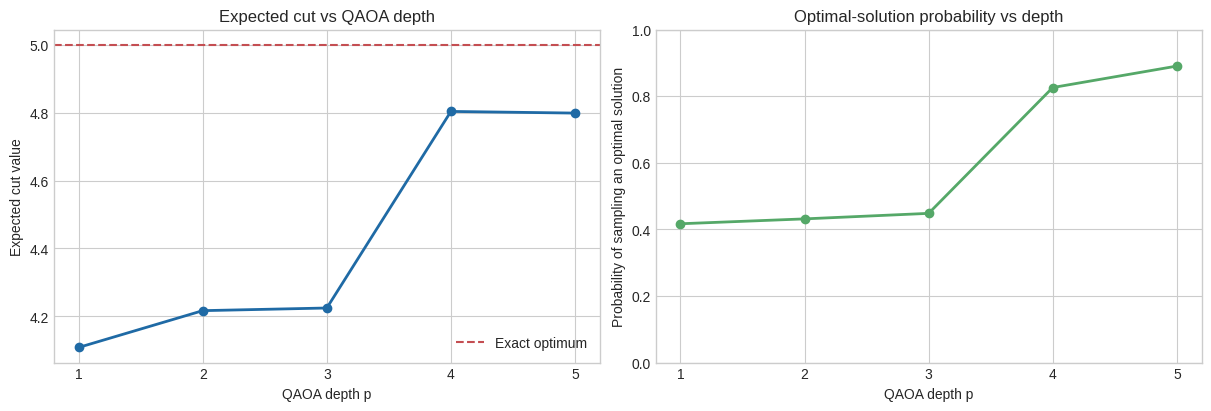

In [42]:
p_values = [entry.layers for entry in layer_sweep.entries]
expected_cuts = [entry.result.expected_cut for entry in layer_sweep.entries]
optimal_probs = [entry.optimal_probability for entry in layer_sweep.entries]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(p_values, expected_cuts, marker='o', linewidth=2, color='#1F6AA5')
axes[0].axhline(layer_sweep.exact_cut, linestyle='--', color='#C44E52', label='Exact optimum')
axes[0].set_xlabel('QAOA depth p')
axes[0].set_ylabel('Expected cut value')
axes[0].set_title('Expected cut vs QAOA depth')
axes[0].set_xticks(p_values)
axes[0].legend()

axes[1].plot(p_values, optimal_probs, marker='o', linewidth=2, color='#55A868')
axes[1].set_xlabel('QAOA depth p')
axes[1].set_ylabel('Probability of sampling an optimal solution')
axes[1].set_title('Optimal-solution probability vs depth')
axes[1].set_xticks(p_values)
axes[1].set_ylim(0.0, 1.0)

plt.show()


The next plot shows the optimized parameter schedules themselves. Each column corresponds to one QAOA depth $p$, and each filled cell gives the optimized angle for layer index $i$ at that depth.


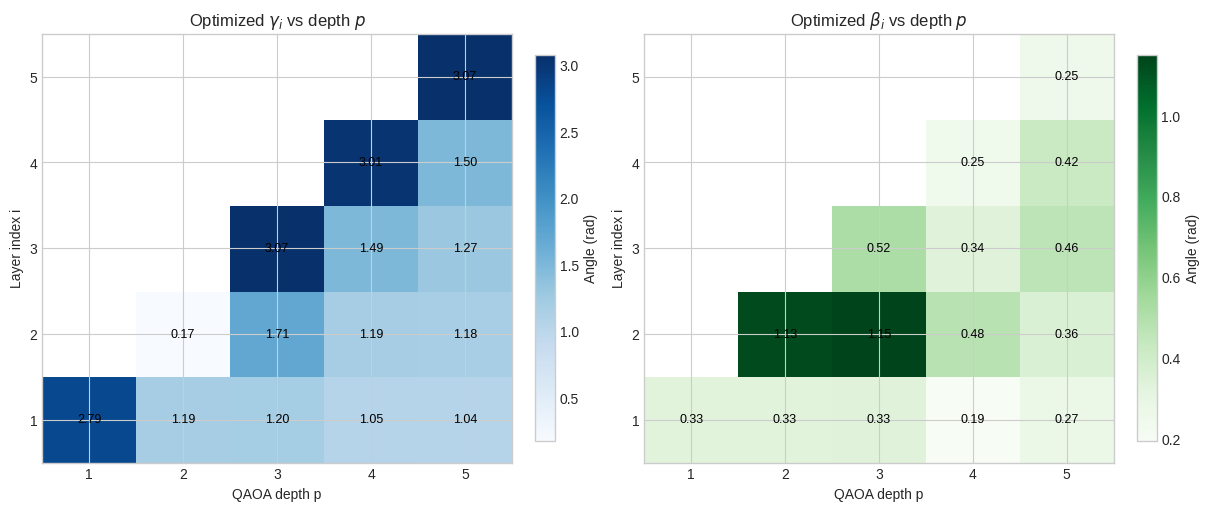

In [43]:
gamma_grid = np.full((max_layers, max_layers), np.nan)
beta_grid = np.full((max_layers, max_layers), np.nan)

for entry in layer_sweep.entries:
    p = entry.layers
    gamma_grid[:p, p - 1] = entry.result.x[:p]
    beta_grid[:p, p - 1] = entry.result.x[p:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, values, title, cmap in [
    (axes[0], gamma_grid, 'Optimized $\\gamma_i$ vs depth $p$', 'Blues'),
    (axes[1], beta_grid, 'Optimized $\\beta_i$ vs depth $p$', 'Greens'),
]:
    masked = np.ma.masked_invalid(values)
    image = ax.imshow(masked, origin='lower', aspect='auto', cmap=cmap, interpolation='none')
    ax.set_xlabel('QAOA depth p')
    ax.set_ylabel('Layer index i')
    ax.set_title(title)
    ax.set_xticks(np.arange(max_layers), labels=np.arange(1, max_layers + 1))
    ax.set_yticks(np.arange(max_layers), labels=np.arange(1, max_layers + 1))

    for row in range(max_layers):
        for col in range(max_layers):
            if np.isfinite(values[row, col]):
                ax.text(col, row, f'{values[row, col]:.2f}', ha='center', va='center', color='black', fontsize=9)

    colorbar = fig.colorbar(image, ax=ax, shrink=0.9)
    colorbar.set_label('Angle (rad)')

plt.show()
